# COURSEWORK SPECIFICATION

## COM1011 - Fundamentals of Machine Learning

**Module Leader:** Chico Camargo

**Academic Year:** 2025/26

**Title:** Coursework 2

**Submission deadline:** 1st December at 12:00pm (noon), 2025.

This assessment contributes **70%** of the total module mark and assesses the following intended learning outcomes:

1. Understanding and identifying the compromises and trade-offs that must be made when using a machine learning approach;
2. Analysing problems from a data-centric point of view, choosing among a range of supervised and unsupervised machine learning techniques and using relevant software libraries to solve them
3. Stating the importance and difficulty of establishing machine learning solutions;
4. Using elementary python for implementing machine learning algorithms.
5. Identifying the compromises that must be made when translating theory into practice


__________________________

# What to submit

You are required to submit your assignment **1st December at 12:00pm (noon), 2025**.

Please do all your work in this Jupyter notebook. Make a separate cell for every few lines of code, and use separate cells for text, like this one.
Save your file in the format `COM1011_STUDENTNUMBER.ipynb` and zip it.
For example, if your student number is 12345678, save your coursework as `COM1011_12345678.ipynb`.
Once you have done that, zip the file, producing a file called `COM1011_12345678.zip`. This is the file you will have to upload and submit to ELE.

This assignment will also use additional CSV files. Do not include them in the `COM1011_STUDENTNUMBER.zip` file.

____________________


# Answer template

Please use this notebook for your coursework. Feel free to add more cells for your code and answers, but try to stick to this format. This will make it easier to mark everyone's work fairly.

___________________

_____________________

# Part A – Probability and Bayesian Inference [10 marks]

Consider a simple poker game. Suppose a deck of poker cards contains four suits: Clubs, Spades, Hearts, and Diamonds, with each suit having 8 cards numbered from 1 to 8. So the total number of cards is 32. The card with the number 8 is the largest, while the card with the number 1 is the smallest. Cards of different suits with the same number are considered equal.

(1) Suppose person A fetches a card with the number 3 of Clubs from the deck. Person B then fetches another card from the deck. What is the probability that person B's card is less than person A's card? Explain how you arrived at the answer. [1 mark]

Answer to (1): 
P = 8/31
Person A draws a card, so the cards remaining in the deck is 31cards, and there are 8 cards in the deck that is less then 3.

(2) If you have drawn four cards sequentially from the deck of 32 cards. What is the total probability that the four cards have the same number 3? (1 mark)


Answer to (2): 
P = (4/32) * (3/31) * (2/30) * (1/29)



(3) If you have drawn four cards sequentially from the deck of 32 cards. What is the total probability that the four cards are of Clubs? Explain how you arrived at the answer [1 mark]

Answer to (2):
P = (8/32) * (7/31) * (6/30) * (5/29)
There are total of 8 clubs in the deck, the total number of clubs and the total number of cards decreases by 1 after ecah card is drawn.


(4) Suppose person A fetches a card with the number 3 of Hearts from the deck. Person B then fetches another card with the number 6 from the deck. What is the probability that person B's card is also of Hearts? Explain how you arrived at the answer by using Bayesian formula. [2 mark]

Answer to (4): 
Let A = person B's card is Hearts, B = person B's card is a 6.
P(A) = 8/32, P(B) = 4/32, P(B|A) = 1/8
P(A|B) = [(1/8) * (8/32)] / (4/32) 
P = 1/4


(5) Suppose person A fetches a card with the number 2 from the deck of 32 cards. Person B then fetches another card with the number 4 from the deck. What is the probability that person B's card and A's card have the same suit? Explain how you arrived at the answer by using Bayesian formula. [2 marks]

Answer to (5):
Let A = person A's suit is person B's suit, B = person B's card is a 4
P(A) = 1/4, P(B) = 4/32, P(B|A) = 1/8
P(A|B) = [(1/8) * (1/4)] / (4/32)
P = 1/4


(6) Briefly explain how  Naive Bayesian classifier works such as how the conditional probability is computed for both the cases of discrete features and contineous features. [2 marks]

What is the major limitation of Naive Bayesian classifier in practice? [1 mark]

Answer to (6): 
Naive Bayesian uses Bayes' theorem to predict the class probability assuming all the feature are independent. For discrete features like catagories or labels, we use frequency counts to count how often a feature value appears in a class. For continous features which are numbers we use Gaussian distribution, which invloves using the Gaussian formula and calculate the class distribution using class mean and variance. And since Naive Bayes assumes all the features are indepent, which usually are unrealistic, therefore the performance will drop in real dataset.

_____________________

# Part B – Clustering and Dimension Reduction [32 marks]

## 1 Implement K-means clustering for fashion-MNIST dataset:

(7) Load the fashion-MNIST test dataset (`t10k-labels-idx1-ubyte.gz` and `t10k-images-idx3-ubyte.gz`), then obtain the image data denoted as `X_test` and the ground truth labels denoted as `y_test`. After that, pre-process `X_test` by scaling the image pixel values to values between 0 and 1. Source code is provided. [0 mark]

[hint: check https://github.com/zalandoresearch/fashion-mnist?tab=readme-ov-file#get-the-data for detailed information about fashion-MNIST dataset]


In [1]:
# answer to (7). You may need to change path for `t10k-labels-idx1-ubyte.gz` and `t10k-images-idx3-ubyte.gz`
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load fashion-MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels


X_test, y_test = load_mnist('D:/University of Exeter/COM1011 Fundamentals of Machine Learning/Coursework/Coursework  2/', kind='t10k')

X_test = X_test/255

print(np.max(X_test))

print(X_test.shape)
print(y_test.shape)


1.0
(10000, 784)
(10000,)


(8) Obtain all the test images and their (ground-truth) labels for '3','6','7', respectively, and then rearrange the samples and labels in a random order. [1 mark]

[hint: check https://numpy.org/doc/2.2/reference/generated/numpy.isin.html and https://numpy.org/doc/2.1/reference/random/generated/numpy.random.permutation.html]



In [2]:
# answer to (8)
selected_labels = [3,6,7]
masked = np.isin(y_test, selected_labels)

In [3]:
X_masked = X_test[masked]
y_masked = y_test[masked]

In [4]:
rearranged = np.random.default_rng(seed=42)
indices = np.arange(len(y_masked))
rearranged.shuffle(indices)

In [5]:
X_masked = X_masked[indices]
y_masked = y_masked[indices]

In [6]:
print(X_masked.shape)
print(y_masked.shape)

(3000, 784)
(3000,)


(9) Use PCA with 2 components to visualise the test data samples in (8) with different colors representing different real (i.e., ground-truth) clusters in a 2d plot. In the plot legend, indicate which colours correspond to which digits. You should use three colors for the three labels: '3','6', '7'. [2 marks]

In [7]:
#Answer to (9)
#perform PCA with 2 components and further visualize the data samples in a 2d plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_masked)

In [8]:
label_colour = {3:'red', 6:'green', 7: 'blue'}

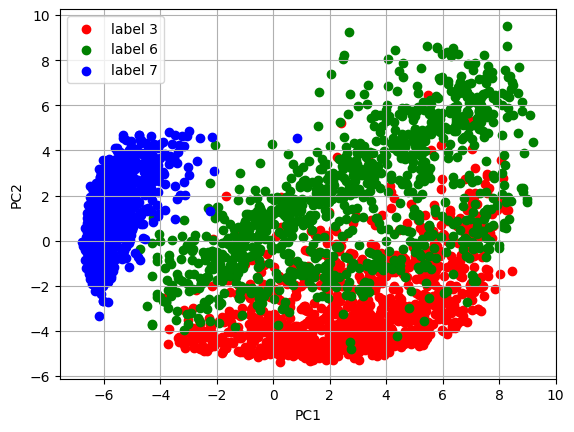

In [9]:
for label, color in label_colour.items():
    mask = (y_masked == label)
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1], c=color, label=f'label {label}')

plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.show()

(10) Using the K-means clustering algorithm to cluster the test images in (8) directly, using k=2, 3 and 4. And then use PCA with 2 components to visualize the test data samples with different colors representing different predicted clusters in a 2d plot for each k value. You need to produce three plots, one plot for each k value. [3 marks]


In [10]:
#answer to (10)
#perform K-means
def kmeans_plot(X, k):
    k_means = KMeans(n_clusters=k, random_state=42)
    cluster_label = k_means.fit_predict(X)
    colors = ['red', 'green' , 'blue', 'orange']

    for cluster in range(k):
        mask = (cluster_label == cluster)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cluster], label=f"Cluster {cluster}")
    
    plt.title(f'K-means Clustering with k={k}')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.show()



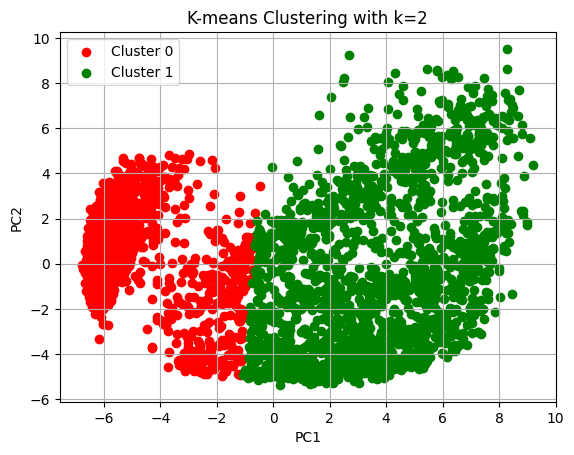

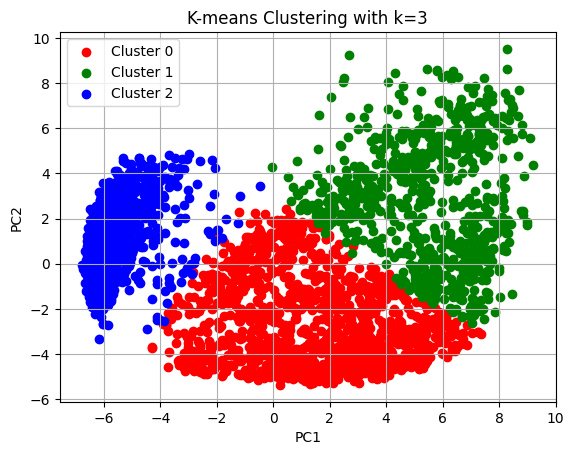

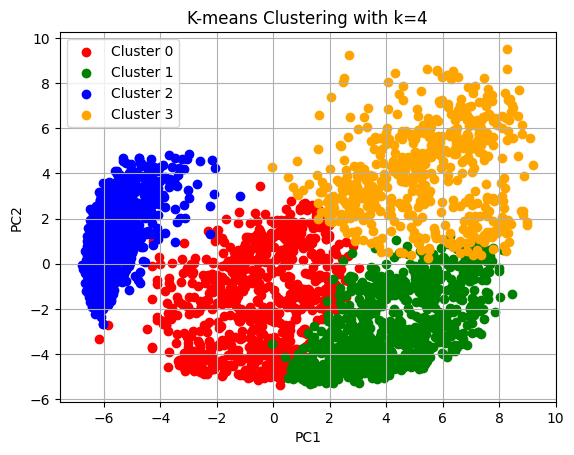

In [11]:
kmeans_plot(X_masked, 2)
kmeans_plot(X_masked, 3)
kmeans_plot(X_masked, 4)

(11) Calculate and print the respective Davies-Bouldin scores for k=2,3,4 in (10). Which k value produces the best clustering, according to the Davies-Bouldin score. Then answer: is it consistent with the ground truth number of clusters from fashion-MNIST?   [2 marks]

In [12]:
#answer to (11)
from sklearn.metrics import davies_bouldin_score
kmeans_2 = KMeans(n_clusters=2, random_state=42)
labels_2 = kmeans_2.fit_predict(X_masked)
db_2 = davies_bouldin_score(X_masked, labels_2)
print("Davies-Bouldin with k=2:", db_2)

kmeans_3 = KMeans(n_clusters=3, random_state=42)
labels_3 = kmeans_3.fit_predict(X_masked)
db_3 = davies_bouldin_score(X_masked, labels_3)
print("Davies-Bouldin with k=3:", db_3)

kmeans_4 = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans_4.fit_predict(X_masked)
db_4 = davies_bouldin_score(X_masked, labels_4)
print("Davies-Bouldin with k=4:", db_4)

Davies-Bouldin with k=2: 1.3941972201688322
Davies-Bouldin with k=3: 1.658804383473437
Davies-Bouldin with k=4: 1.5912649026665844


continued answer to (11)

According to the Davies-Bouldin score, k=2 provide the best clustering with the lowest socre, but the result is not consistant to the dataset ground truth number.

 (12) Calculate and print the respective silhouette_scores for k=2,3,4 in (10). Which k value produces the best clustering, according to the Silhouette score. Then answer: is it consistent with the ground truth number of clusters from fashion-MNIST?  [2 marks]

In [13]:
#answer to (12)
from sklearn.metrics import silhouette_score
sc_2 = silhouette_score(X_masked, labels_2)
print("Silhouette score with k=2:", sc_2)

sc_3 = silhouette_score(X_masked, labels_3)
print("Silhouette score with k=3:", sc_3)

sc_4 = silhouette_score(X_masked, labels_4)
print("Silhouette score with k=4:", sc_4)


Silhouette score with k=2: 0.27521299065752547
Silhouette score with k=3: 0.2399680631435659
Silhouette score with k=4: 0.22364289930854597


Continued answer to (12)

According to the Silhouette score, k=2 provide the best clustering with the highest socre, but the result is not consistant to the dataset ground truth number.


(13) Using the K-means clustering algorithm to cluster the first two components of PCA being applied to the tested images, using k=2, 3 and 4. And then compare the clustering results with those from (10) by making of 2 subplots for each value of k: one subplot with the clustering done on the whole images, one sublplot with the clustering done with just the two first components of the PCA. [2 marks]


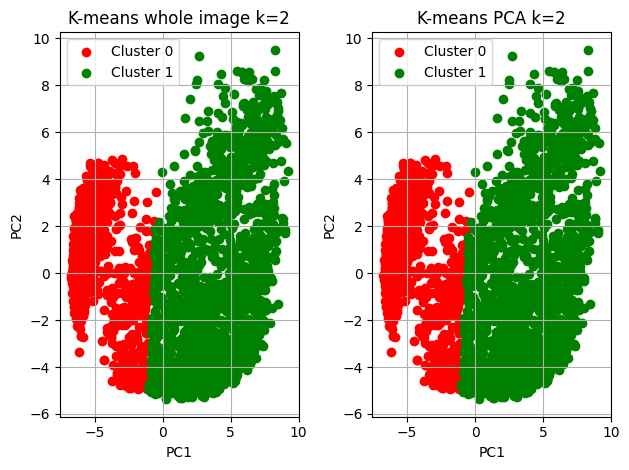

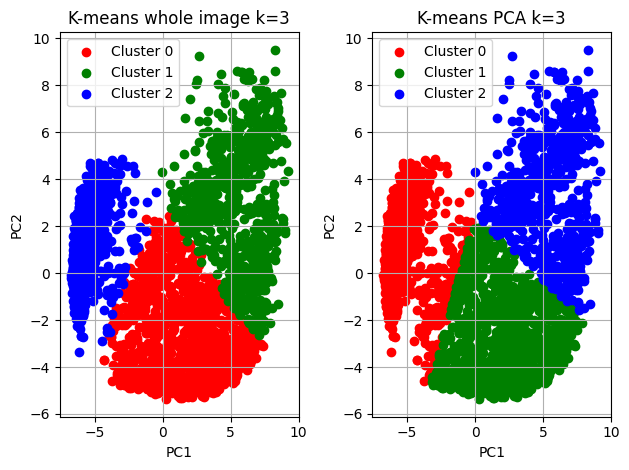

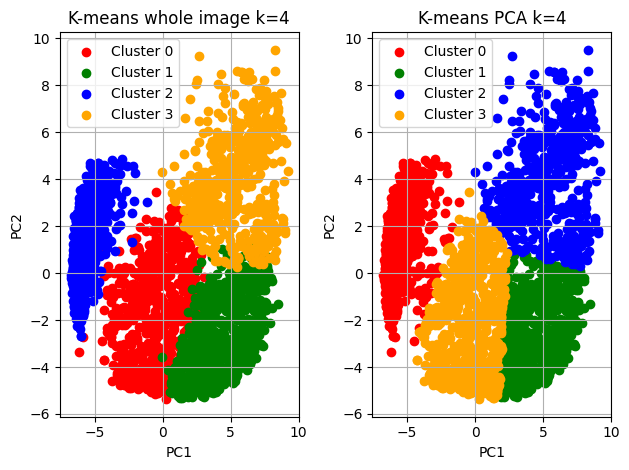

In [14]:
#answer to (13)
#perform K-means
colors = ['red', 'green', 'blue', 'orange']

for k in [2, 3, 4]:
    kmeans_whole_image = KMeans(n_clusters=k, random_state=42)
    labels_whole_image = kmeans_whole_image.fit_predict(X_masked)
    kmeans_pca = KMeans(n_clusters=k, random_state=42)
    labels_pca = kmeans_pca.fit_predict(X_pca)

    plt.subplot(1, 2, 1)
    for cluster in range(k):
        mask = (labels_whole_image == cluster)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cluster], label=f"Cluster {cluster}")
    plt.title(f"K-means whole image k={k}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for cluster in range(k):
        mask = (labels_pca == cluster)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cluster], label=f"Cluster {cluster}")
        
    plt.title(f"K-means PCA k={k}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


(14) Compute the Silhouette scores for different k values in (13) and then compare with those obtained in (12). Answer: are the Silhouette scores obtained from the clustering of whole images consistent with the Silhouette scores obtained by clustering only the two first PCA components?  
[2 marks]


In [15]:
#answer to (14)
from sklearn.metrics import silhouette_score
for k in [2, 3, 4]:

    kmeans_pca = KMeans(n_clusters=k, random_state=42)
    labels_pca = kmeans_pca.fit_predict(X_pca)
    pca_sc = silhouette_score(X_pca, labels_pca)

    print(f"PCA Silhouette score with k={k}: {pca_sc}")


PCA Silhouette score with k=2: 0.5138526534674457
PCA Silhouette score with k=3: 0.517996181947549
PCA Silhouette score with k=4: 0.4893696466765907


In [16]:
sc_2 = silhouette_score(X_masked, labels_2)
print("Silhouette score with k=2:", sc_2)

sc_3 = silhouette_score(X_masked, labels_3)
print("Silhouette score with k=3:", sc_3)

sc_4 = silhouette_score(X_masked, labels_4)
print("Silhouette score with k=4:", sc_4)

Silhouette score with k=2: 0.27521299065752547
Silhouette score with k=3: 0.2399680631435659
Silhouette score with k=4: 0.22364289930854597


Continued answer to (14)

No, the results are not consistant with each other

(15) Let's compare the result of dimensionality reductions by PCA with 2 components and tSNE with 2 components. Apply PCA and tSNE to the test images of '3', '6', and '7', and then visualize the results in 2 subplots, one for each method. Use different colors to represent different real (ground truth) clusters.  [2 marks]  

In [17]:
#answer to (15)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_masked)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_masked)

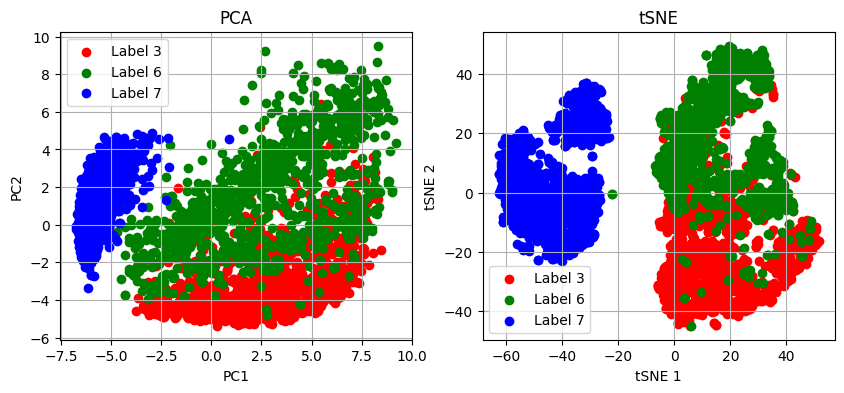

In [18]:
colors = {3: 'red', 6: 'green', 7: 'blue'}

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
for label, color, in colors.items():
    mask = (y_masked == label)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=f'Label {label}')
    plt.title('PCA')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True)

plt.subplot(1,2,2)
for label, color, in colors.items():
    mask = (y_masked == label)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=f'Label {label}')
    plt.title('tSNE')
    plt.xlabel('tSNE 1')
    plt.ylabel('tSNE 2')
    plt.legend()
    plt.grid(True)

plt.show()

## 2. Implementing DBSCAN clustering for classes of '3', '6', and '7' of fashion-MNIST dataset:


(16) Firstly, use the DBSCAN clustering algorithm to cluster the test images directly by setting the eps parameter to 0.3 and the min_sample to 5. And then apply DBSCAN to cluster the first 2 PCA components of the test images by setting the eps parameter to 0.3 and the min_sample to 5.
Visualize the clustering results in two subplots for each k value and also print out the numbers of estimated clusters. [2 marks]






In [19]:
#Answer for (16)
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_masked)

In [20]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_masked)

In [21]:
dbscan_pca = DBSCAN(eps=0.3, min_samples=5)
labels_pca_dbscan = dbscan_pca.fit_predict(X_pca)

In [22]:
dbscan_cluster_count = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
dbscan_pca_cluster_count = len(set(labels_pca_dbscan)) - (1 if -1 in labels_pca_dbscan else 0)

In [23]:
print("Number of clusters (DBSCAN):", dbscan_cluster_count)
print("Number of clusters (DBSCAN with PCA):", dbscan_pca_cluster_count)

Number of clusters (DBSCAN): 0
Number of clusters (DBSCAN with PCA): 33


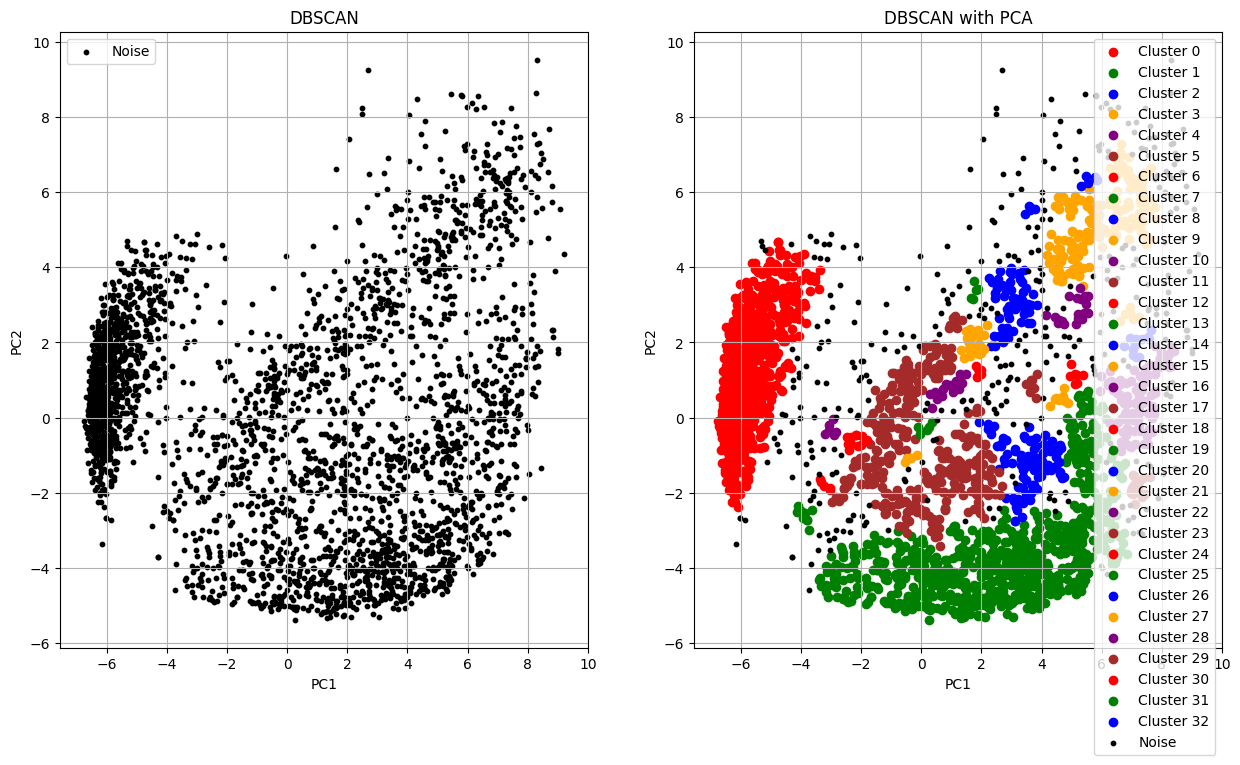

In [24]:
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']
noise = 'black'

plt.figure(figsize=(15,8))

plt.subplot(1, 2, 1)
for cluster in set(labels_dbscan):
    mask = (labels_dbscan == cluster)
    if cluster == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=noise, s=10, label='Noise')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cluster % len(colors)], label=f'Cluster {cluster}')
plt.title('DBSCAN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)

# RIGHT: DBSCAN with PCA
plt.subplot(1, 2, 2)
for cluster in set(labels_pca_dbscan):
    mask = (labels_pca_dbscan == cluster)
    if cluster == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=noise, s=10, label='Noise')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cluster % len(colors)], label=f'Cluster {cluster}')
plt.title('DBSCAN with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)

plt.show()


(17) Changing the eps parameter in (16) to 0.5 and 1, and briefly summarize your observations of the experimental results in terms of the stability of the DBSCAN method in comparison to K-means: is DBSCAN more or less stable than K-means, when it comes to changing hyperparameters? [2 marks]


In [25]:
eps_values = [0.5, 1.0]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels_db = dbscan.fit_predict(X_pca)

    clusters_count = len(set(labels_db)) - (1 if -1 in labels_db else 0)

    print(f'Clusters count with eps = {eps}: {clusters_count}')


Clusters count with eps = 0.5: 5
Clusters count with eps = 1.0: 1


Answer to (17)

When increasing the eps for DBSCAN, the number of cluster changes drastically. On the other hand, k-means are more stable and predictable by controlling the k parameter.

(18) Compare the performance of K-means and DBSCAN when clustering the data points obtained by applying tSNE with 2 components on test images of classes '3', '6', and '7'.

Set k in K-means to k=3. Play with different values of (eps, min_samples) in DBSCAN to find a proper setup. Visualize the clustering results in 2 subplots. Answer: which method is more robust from the above results? How did you arrive at that conclusion? [2 marks]


In [26]:
#Answer to (18)
from sklearn.manifold import TSNE
kmeans_tsne = KMeans(n_clusters=3, random_state=42)
labels_kmeans_tsne = kmeans_tsne.fit_predict(X_tsne)

In [27]:
dbscan_tsne = DBSCAN(eps=3, min_samples=5)
labels_dbscan_tsne = dbscan_tsne.fit_predict(X_tsne)

In [28]:
dbscan_tsne_clusters = len(set(labels_dbscan_tsne)) - (1 if -1 in labels_dbscan_tsne else 0)
print(f'Clusters count with DBSCAN on tSNE:, {dbscan_tsne_clusters}')

Clusters count with DBSCAN on tSNE:, 6


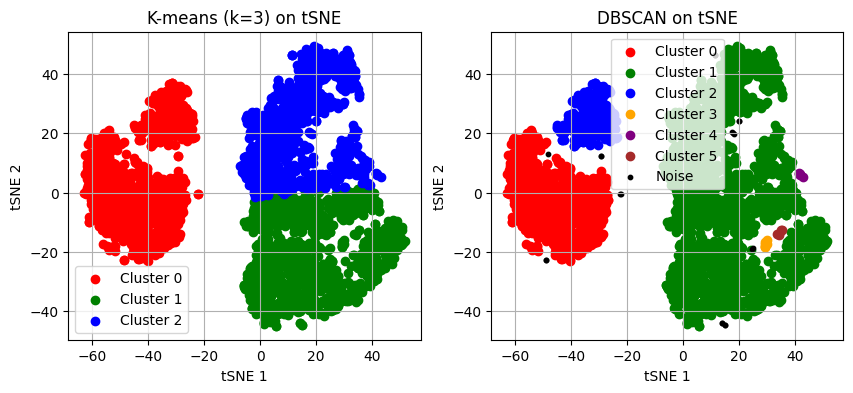

In [29]:
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']
noise = 'black'

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
for cluster in set(labels_kmeans_tsne):
    mask = (labels_kmeans_tsne == cluster)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[cluster % len(colors)], label=f'Cluster {cluster}')
plt.title('K-means (k=3) on tSNE')
plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for cluster in set(labels_dbscan_tsne):
    mask = (labels_dbscan_tsne == cluster)
    if cluster == -1:
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=noise, s=10, label='Noise')
    else:
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[cluster % len(colors)], label=f'Cluster {cluster}')
plt.title('DBSCAN on tSNE')
plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')
plt.grid(True)
plt.legend()

plt.show()

Continued answer to (18).

In this case, k-means is better then DBSCAN according to the results. Because we are in control of how many clusters we want by modifing the k value, giving smoother shapes, samll changes on the parameter will still have similiar results. On the other hand, the output of DBSCAN can change drastically by changing the eps. Small eps can cause too many unmeanful clusters, and big eps can cause important cluster merges together.


(19) Implement bisecting K-means algorithm and Gausian mixture models to cluster the 2 components of tSNE for the test images of classes '3', '6', and '7'. Set the number of clusters to be 3.    [2 marks]

In [30]:
# Answer to (19)
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.cluster import BisectingKMeans
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import numpy as np

bkm = BisectingKMeans(n_clusters=3, random_state=42)
bisect_labels = bkm.fit_predict(X_tsne)

In [31]:
gm = GaussianMixture(n_components=3, random_state=42)
gm_labels = gm.fit_predict(X_tsne)


(20). Usually, DBSCAN takes longer than K-means to run, and the time it takes to run is affected by the eps parameter. Explain why that is the case. [4 marks]

Answer to (20)

Firstly, DBSCAN must find any neighbouring data points winth the eps radius by checking the distance of every other point, which increase the time for calculation when the clusters are close to each other. Secondly, the performance of DBSCAN depends on the eps raduis. When the eps is large, the more points will fall into the eps radius. Therefore, more distance between the data points needs to be calculated. On the other hand, K-means only need to callculate the distance of each data point to the centroids of the cluster, makes is less sensitive to its parameters. Therefore, DBSCAN takes longer time then K-means to run.

(21). Provide an example of one case in which it might be better to use DBSCAN rather than K-means, and an example of one case in which it might be better to use K-means rather than DBSCAN. Explain why, in both cases. [4 marks]

When the data contain cluster with irregular shape and heavy noise, DBSCAN will perform better then K-means. Because DBSCAN will detact unevenly shaped cluster and treat noise as another seperate cluster. But K-means will create a more even shaped cluster and include noise, therefore the result of the data might not be present in the most accurate way. But if the data includes a large circluar cluster without a lot of noise, K-means will perform better, becasue it is trying to assign each data point to the nearest centroid and place them in the mean distance in its cluster, and there is no need to handle the noise like DBSCAN does. Therefore a evenly shape cluster will work in favor of K-means clustering.

Answer to (21):





_____________________

# Part C – Classification and Regression [32 marks]

## 1 Implement a multi-class Logistic Regression classifier for fashion-MNIST dataset.  [20 marks]

(22) Load "train-labels-idx1-ubyte.gz" and "train-images-idx3-ubyte.gz". In the variable X_tmp (see the code below), every row represents a greyscale image, and every one of the 784 columns represent a pixel value. 784 = 28 x 28. So each image is size 28*28.

First, load the two files "train-labels-idx1-ubyte.gz" and "train-images-idx3-ubyte.gz". Then, perform train-test-split to prepare both the training data in terms of (X_train, y_train) and test data in terms of (X_test, y_test). The code for this question is provided below to faciliate the implementation for the following questions. [0 mark]

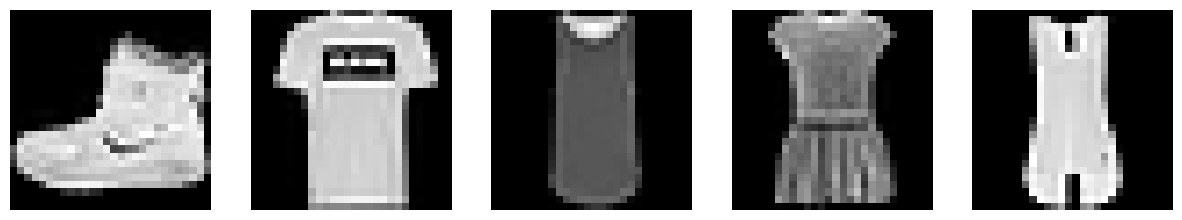

In [32]:
# answer for (22). You may need to change the path for "train-labels-idx1-ubyte.gz" and "train-images-idx3-ubyte.gz".
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import numpy as np


def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load fashion-MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels


X_tmp, y_tmp = load_mnist('D:/University of Exeter/COM1011 Fundamentals of Machine Learning/Coursework/Coursework  2/', kind='train')

# normalization
X_tmp = X_tmp/255.0


plt.figure(figsize=(15,3))
for i in range(5):
  image = X_tmp[i,:].reshape(28,28)
  plt.subplot(1, 5, i+1)
  plt.imshow(image, cmap='gray')
  plt.axis('off')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=1)

(23)

Implement a two-class Logistic Regression classifer for classes with labels 4 and 6 in fashion-MNIST by using LogisticRegression from `sklearn.linear_model`. Set random_state to 42, solver='sag' and max_iter=200 in LogisticRegression- (look at the documentation online if needed). Print both the training and test classfication accuracices. [1 mark]

In [33]:
#answer to (23)
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

mask_train = (y_train == 4) | (y_train == 6)
X_train_masked = X_train[mask_train]
y_train_masked = y_train[mask_train]

mask_test = (y_test == 4) | (y_test == 6)
X_test_masked = X_test[mask_test]
y_test_masked = y_test[mask_test]

In [34]:
log_reg = LogisticRegression(random_state=42, solver='sag', max_iter=200)
log_reg.fit(X_train_masked, y_train_masked)

d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursework  2\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'sag'
,max_iter,200
,multi_class,'deprecated'


In [35]:
y_pred_train = log_reg.predict(X_train_masked)
y_pred_test = log_reg.predict(X_test_masked)

In [36]:
train_acc = accuracy_score(y_train_masked, y_pred_train)
test_acc = accuracy_score(y_test_masked, y_pred_test)

In [37]:
print(f'Train accuracy: {train_acc}')
print(f'Test accuracy: {test_acc}')

Train accuracy: 0.9005484839076892
Test accuracy: 0.8818998716302953


(24) Test solver='sag', random_state=42, and max_iter={300, 500} in (23). Print both the training and test classfication accuracices. [2 marks]

In [38]:
# answer to (24)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
log_reg_300 = LogisticRegression(random_state=42, solver='sag', max_iter=300)
log_reg_300.fit(X_train_masked, y_train_masked)

d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursework  2\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'sag'
,max_iter,300
,multi_class,'deprecated'


In [39]:
train_pred_300 = log_reg_300.predict(X_train_masked)
test_pred_300 = log_reg_300.predict(X_test_masked)

In [40]:
train_acc_300 = accuracy_score(y_train_masked, train_pred_300)
test_acc_300 = accuracy_score(y_test_masked, test_pred_300)
print(f'Training accuracy (max_iter = 300): {train_acc_300}')
print(f'Test accuracy (max_iter = 300): {test_acc_300}')

Training accuracy (max_iter = 300): 0.9009624340266997
Test accuracy (max_iter = 300): 0.881471972614463


In [41]:
log_reg_500 = LogisticRegression(random_state=42, solver='sag', max_iter=500)
log_reg_500.fit(X_train_masked, y_train_masked)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'sag'
,max_iter,500
,multi_class,'deprecated'


In [42]:
train_pred_500 = log_reg_500.predict(X_train_masked)
test_pred_500 = log_reg_500.predict(X_test_masked)

In [43]:
train_acc_500 = accuracy_score(y_train_masked, train_pred_500)
test_acc_500 = accuracy_score(y_test_masked, test_pred_500)
print(f'Training accuracy (max_iter = 500): {train_acc_500}')
print(f'Test accuracy (max_iter = 500): {test_acc_500}')

Training accuracy (max_iter = 500): 0.9010659215564525
Test accuracy (max_iter = 500): 0.881471972614463


(25) Plot both the training and test accuracies for the maximum iterations of 200, 300,  500 being set in LogisticRegression, based on the results from (23) and (24). Put the two curves (one for the training curve and the other for the test curve) in the same 2d plot for easy comparison. Make X axis be the number of maximum iterations (200, 300, 500) and the y axis be the accuracy. [1 mark]

In [44]:
# Answer to (25)
iterations = [200, 300, 500]
train_accuracies = [train_acc, train_acc_300, train_acc_500]
test_accuracies  = [test_acc,  test_acc_300,  test_acc_500]


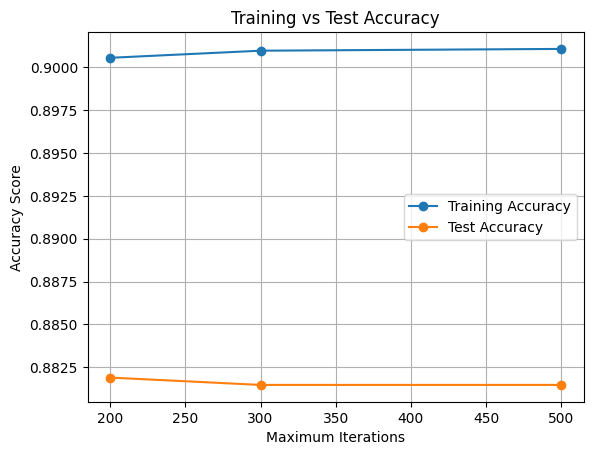

In [45]:
plt.figure()
plt.plot(iterations, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(iterations, test_accuracies, marker='o', label='Test Accuracy')
plt.xlabel('Maximum Iterations')
plt.ylabel('Accuracy Score')
plt.title('Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

(26) Three classification models have been obtained from (23) and (24) by setting different values for the hyper-parameter max_iter. Which model should we choose? Explain why. [1 mark]

Comparing all 3 models, we should choose the one with the highest accuracy score. But since all three models performs very similiar with a test accuracy score of 0.881. In this instance, we should choose the model with max_iter of 200, because it is simplier and uses less optimisation steps.

What is overfitting? Why is that a problem, and how can one avoid it? [3 marks]

Overfitting is when a model picks up the noise and unimportant data instead of the general parttern of the data, which cause inaccurate results in real applications. We can use cross-validation and optimise the hyperparameters by comparing the model performance. Also we can choose features more selectively, using more relavent features can filter noise and unimportant data, giving more accurate results.


Does the plot in (25) exhibit over-fitting? Explain why. [1 mark]

The plot on 25 doesn't show overfitting. The graph shows the gap between training and test accuracy is very small at around 2%, meaning the model generalises the data reasonably well.



Answer to (26):

(27) Let's do some data augmentation to improve the test performance in (23) and (24). In doing so, prepare additional training data for class 4 and 6 of fashion-MNIST by flipping each image horizontally using a library like numpy.flip. Display one original image alongside its flipped version to demonstrate the augmentation.   [2 marks]

Then, use both the original training data and the flipped training data to train the two-class Logistic Regression classifer. Print out the training and test accuracies for max_iter = {200, 300, 500}.  [2 marks]

In [46]:
# Answer to (27)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from scipy.ndimage import rotate
X_train_reshape = X_train_masked.reshape(-1, 28, 28)
X_train_flip = np.flip(X_train_reshape, axis=2)
X_train_flip = X_train_flip.reshape(-1, 784)
y_train_flip = y_train_masked.copy()

In [47]:
X_train_aug = np.vstack([X_train_masked, X_train_flip])
y_train_aug = np.hstack([y_train_masked, y_train_flip])

In [48]:
idx_4 = np.where(y_train_masked == 4)[0][0]
idx_6 = np.where(y_train_masked == 6)[0][0]

In [49]:
img4_ori = X_train_reshape[idx_4]
img4_flip  = X_train_flip.reshape(-1,28,28)[idx_4]

img6_ori = X_train_reshape[idx_6]
img6_flip  = X_train_flip.reshape(-1,28,28)[idx_6]

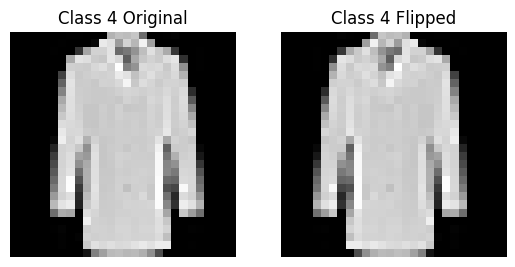

In [50]:
plt.figure()
plt.subplot(1,2,1)
plt.imshow(img4_ori, cmap='gray')
plt.title('Class 4 Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img4_flip, cmap='gray')
plt.title('Class 4 Flipped')
plt.axis('off')
plt.show()


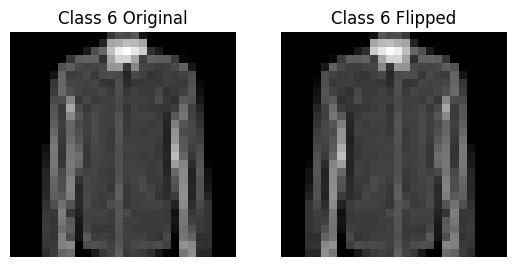

In [51]:
plt.figure()
plt.subplot(1,2,1)
plt.imshow(img6_ori, cmap="gray")
plt.title("Class 6 Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img6_flip, cmap="gray")
plt.title("Class 6 Flipped")
plt.axis("off")
plt.show()

In [52]:
iter = [200, 300, 500]

for it in iter:
    log_reg = LogisticRegression(random_state=42, solver='sag', max_iter=it)
    log_reg.fit(X_train_aug, y_train_aug)

    train_pred = log_reg.predict(X_train_aug)
    test_pred = log_reg.predict(X_test_masked)

    train_acc = accuracy_score(y_train_aug, train_pred)
    test_acc = accuracy_score(y_test_masked, test_pred)

    print(f'Training accuracy (max_iter = {it}): {train_acc}')
    print(f'Test accuracy (max_iter = {it}): {test_acc}')

d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursework  2\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training accuracy (max_iter = 200): 0.8888026492807617
Test accuracy (max_iter = 200): 0.8789045785194695


d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursework  2\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Training accuracy (max_iter = 300): 0.888854393045638
Test accuracy (max_iter = 300): 0.8789045785194695
Training accuracy (max_iter = 500): 0.888854393045638
Test accuracy (max_iter = 500): 0.8789045785194695


(28) In general, is the image-flip technique a reasonable approach for the considered classification problem? Provide your reasoning. [2 marks]

Is the test accuracy obtained in (27) better than those in (23) and (24)? [1 mark]

Consider three approaches: 1-change to advanced machine learning models, 2-employ other data augmentation techniques, 3-employ other data pre-processing techniques.  What do you think is the most effective approach to improve the test performance ? Why. [2 marks]

Elaborate on the most effective approach you have chosen by providing more detailed suggestions. [2 marks]

Answer to (28):

In general, the image-flip technique is a resonable approach for class 4 and 6. Because these 2 class are coat and shirt items, and they will looks roughly the same when flipped left to right. Therefore flipping the imaage won't an effect on the true label of the picture.

No, the test accuracy of (27) is slightly lower then (23) and (24).

The most effective way to imporve the test performance is to change to an advanced machine learing model. Because logistic regression is a linear classifier, for a dataset like the Fashion_MNIST which has no clear linear patterns in the data, logistic regression will almost always struggle to provide a more accurate result. 

Models that involves neural-networks, like CNN will likely to perform better on a MNIST dataset. Given that it can learn more complex non-linear pattern like edges and the strokes in the images, making CNN a significant better model then logistic regression, which is only linear classifier.

## 2 Implement regression for the housing dataset.  [12 marks]

(29) Check how normalization affects the regression performance with the dataset "housing.csv".

Firstly, visualize the correlation matrix in terms of the heat map for all the 14 features. [0.5 mark]

Secondly, implement a Linear model that use only the 'CRIM' and 'RM' to predict 'TAX' without normalization. In doing so, split the data into training and test datasets. Report both the training and test errors in terms of mean squared error (MSE). [0.5 mark]  

Thirdly, do normalization (refer to the operation of scaling each feature to be in the range of [0,1]) to the data, and then implement a Linear model that use normalized 'CRIM' and normalized 'RM' to predict normalized 'TAX'. Report both the training and test errors.  What conclusions can you draw by comparing the above prediction results regarding the impact of normalization? [1 mark]  





In [68]:
# Answer to (29)
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler


column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

regression_data = pd.read_csv('D:/University of Exeter/COM1011 Fundamentals of Machine Learning/Coursework/Coursework  2/housing.csv')

#regression_data=regression_data.astype(float)

correlation_matrix = regression_data.corr()

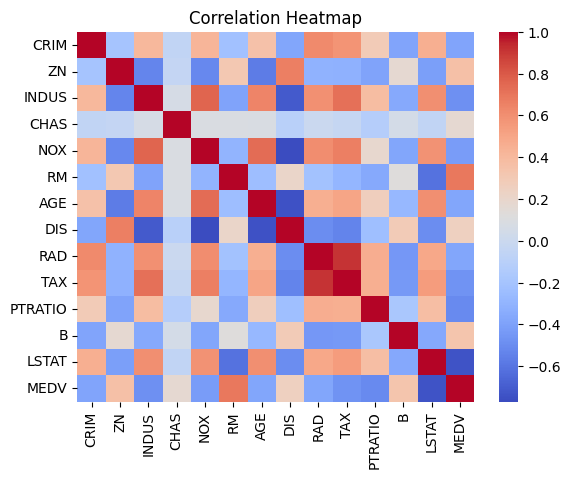

In [54]:
plt.figure()
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [55]:
X = regression_data[['CRIM', 'RM']]
y = regression_data['TAX']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



In [56]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
train_pred = lin_reg.predict(X_train)
test_pred = lin_reg.predict(X_test)

In [58]:
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print(f'Training MSE: {train_mse}')
print(f'Test MSE: {test_mse}')

Training MSE: 16932.196080941307
Test MSE: 23367.346744526265


In [59]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm = scaler_X.transform(X_test)
y_train_norm = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_norm = scaler_y.transform(y_test.values.reshape(-1, 1))

In [60]:
lin_reg_norm = LinearRegression()
lin_reg_norm.fit(X_train_norm, y_train_norm)
train_pred_norm = lin_reg_norm.predict(X_train_norm)
test_pred_norm = lin_reg_norm.predict(X_test_norm)

In [66]:
train_mse_norm = mean_squared_error(y_train_norm, train_pred_norm)
test_mse_norm = mean_squared_error(y_test_norm, test_pred_norm)

print(f'Normalized Training MSE: {train_mse_norm}')
print(f'Normalized Test MSE: {test_mse_norm}')


Normalized Training MSE: 0.061666700953256326
Normalized Test MSE: 0.08510338392476495


Continued answer to (29):

Normalization can improve the model stability by reduces the scale differences large range and samll range. The model with normalization generally show a lower MSE compare to model without normalization. 


(30) Check how correlation strength affects the regression performance with the dataset "housing.csv".

Use normlized "CRIM" and normalized "ZN" to predict normalized "TAX" by using a linear model. Print out the training and test mean squared error. Remember using the same random_state and the same test_size when running the train_test_split function from sklearn.model_selection.   [1 mark]  

Use normlized "CRIM" and normalized "INDUS" to predict normalized "TAX" by using a linear model. Print out the training and test mean squared error. Remember using the same random_state and the same test_size when running the train_test_split function from sklearn.model_selection.   [1 mark]  





In [70]:
# Answer to (30)
scaler_y = MinMaxScaler()
y_train_norm = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_norm = scaler_y.transform(y_test.values.reshape(-1, 1))
X = regression_data[['CRIM', 'ZN']]

In [71]:
X_train_CZ, X_test_CZ, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
scaler_X = MinMaxScaler()
X_train_CZ_norm = scaler_X.fit_transform(X_train_CZ)
X_test_CZ_norm = scaler_X.transform(X_test_CZ)

In [75]:
model = LinearRegression()
model.fit(X_train_CZ_norm, y_train_norm)
train_pred_CZ = model.predict(X_train_CZ_norm)
test_pred_CZ = model.predict(X_test_CZ_norm)

In [77]:
print('Training MSE:', mean_squared_error(y_train_norm, train_pred_CZ))
print('Test MSE:', mean_squared_error(y_test_norm, test_pred_CZ))

Training MSE: 0.10258249736630468
Test MSE: 0.10601370376193912


In [78]:
X = regression_data[['CRIM', 'INDUS']]
X_train_CI, X_test_CI, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
scaler_X = MinMaxScaler()
X_train_CI_norm = scaler_X.fit_transform(X_train_CI)
X_test_CI_norm = scaler_X.transform(X_test_CI)

In [80]:
model = LinearRegression()
model.fit(X_train_CI_norm, y_train_norm)
train_pred_CI = model.predict(X_train_CI_norm)
test_pred_CI = model.predict(X_test_CI_norm)

In [81]:
print('Training MSE:', mean_squared_error(y_train_norm, train_pred_CI))
print('Test MSE:', mean_squared_error(y_test_norm, test_pred_CI))

Training MSE: 0.10259092781356993
Test MSE: 0.10611244598690873


(31) What conclusions can you draw by comparing the test errors of (29) and (30) regarding the impact of the correlation strength (check the heat map shown above)? [1 mark]

Answer to (31):

Form comparing the test error in both questions, we can conclude that the stronger the feature correlate to the target, the lower the test error.

(32) Convert a regression problem to a classification problem of 10 classes.

First pre-processing the data for "TAX" to be in the range of [0,10) denoted as yy in the data type of float. Then tranform (via the rounding opertion) yy into the data type of integer within {0,1,2,.., 9} denoted as y. [1 mark]

Obtain training and test datasets from  normlized "CRIM", normalized "INDUS", and the ground truth labels y. Then implement a Logistic classifer and report the training and test accuracies.  Set random_state to 42, solver='sag' and max_iter=200 in LogisticRegression. [1 mark]

Rescale the prediced labels from the Logistic classifer to the range of [0, 1] and then compute and print out the mean squqred errors (MSEs) with respect to the normalized ground truth "TAX" for both training and test datasets.  [1 mark]

Compare the obtained MSEs with those in (30). Which method produces lower MSE for test dataset?  Which method produces lower MSE for training dataset? Do you think converting a regression problem to a classification problem is a resonable approch in general? [1 mark]


In [82]:
#Answer to (32)
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
yy = (regression_data['TAX'] - regression_data['TAX'].min()) / \
     (regression_data['TAX'].max() - regression_data['TAX'].min()) * 10
y_class = yy.round().astype(int)

In [83]:
X = regression_data[['CRIM', 'INDUS']]
y = y_class
scaler_X = MinMaxScaler()

In [84]:
X_train, X_test, y_train_cls, y_test_cls = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm = scaler_X.transform(X_test)

In [85]:
scaler_tax = MinMaxScaler()
tax_train_norm = scaler_tax.fit_transform(regression_data['TAX'].iloc[y_train_cls.index].values.reshape(-1,1))
tax_test_norm  = scaler_tax.transform(regression_data['TAX'].iloc[y_test_cls.index].values.reshape(-1,1))

In [86]:
log_reg = LogisticRegression(random_state=42,solver='sag',max_iter=200)
log_reg.fit(X_train_norm, y_train_cls)
train_pred_cls = log_reg.predict(X_train_norm)
test_pred_cls = log_reg.predict(X_test_norm)

In [87]:
train_acc = accuracy_score(y_train_cls, train_pred_cls)
test_acc = accuracy_score(y_test_cls, test_pred_cls) 

In [96]:
print('Training accuracy:', train_acc)
print('Test accuracy:', test_acc)

Training accuracy: 0.5371287128712872
Test accuracy: 0.5882352941176471


In [98]:
train_pred_scaled = train_pred_cls / 9.0
test_pred_scaled  = test_pred_cls / 9.0

In [99]:
mse_train = mean_squared_error(tax_train_norm, train_pred_scaled)
mse_test  = mean_squared_error(tax_test_norm, test_pred_scaled)

In [101]:
print('Training MSE:', mse_train)
print('Test MSE:', mse_test)

Training MSE: 0.06028304750890567
Test MSE: 0.03957765145832702


Continued answer to (32)

Linear regression gives lower MSE on both training and test dataset. Coverting regresion to classification is generally not recommanded. Because regression preserves all continous information, and classification only copress the target into only 10 classes. This will cause rounding error and lower ther accuracy of the model.




(33) Convert the same regression problem in (32) to a classification problem of 100 classes. Set random_state to 42, solver='sag' and max_iter=200 in LogisticRegression. Report the MSEs for both training and test datasets.  [1 mark]

Compare the obtained MSEs with those of the classification method in (32).
Is the performance get better? [1 mark]

How to futher improve the peformance of the classification method? [1 mark]

In [89]:
#Answer to (33)
yy_100 = y_train_norm.flatten() * 10
y_train_100 = np.round(yy_100).astype(int)
yy_test_100 = y_test_norm.flatten() * 100
y_test_100 = np.round(yy_test_100).astype(int)


In [92]:
log_reg_100 = LogisticRegression(random_state=42 ,solver='sag', max_iter=200, multi_class='multinomial')
log_reg_100.fit(X_train_norm, y_train_100)

d:\University of Exeter\COM1011 Fundamentals of Machine Learning\Coursework\Coursework  2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'sag'
,max_iter,200
,multi_class,'multinomial'


In [93]:
train_pred_labels_100 = log_reg_100.predict(X_train_norm)
test_pred_labels_100 = log_reg_100.predict(X_test_norm)
train_pred_rescaled_100 = train_pred_labels_100 / 100
test_pred_rescaled_100 = test_pred_labels_100 / 100

In [94]:
train_mse_100 = mean_squared_error(y_train_norm, train_pred_rescaled_100)
test_mse_100 = mean_squared_error(y_test_norm, test_pred_rescaled_100)

In [95]:
print('Training MSE (100 classes):', train_mse_100)
print('Test MSE (100 classes):', test_mse_100)

Training MSE (100 classes): 0.2580060226647919
Test MSE (100 classes): 0.2854441616935801


Continued answer to (33)

Comparing the MSE with classification, the performance didn't improve.

We can imporve the model by adding more features with strong correlation to the dataset.

________________

# Part D – Dimensionality reduction [9 marks]

Consider a scenario where you are working with a high-dimensional dataset derived from an ecological study to classify the health status of tree species based on traits such as leaf size, trunk diameter, and soil nutrient levels. The data is expected to have both linear and non-linear relationships, and you aim to reduce the dimensionality for visualization to identify potential clusters (e.g., healthy vs. diseased trees) and preprocessing for a downstream classification task.

(34)	Discuss the advantages and disadvantages of using PCA, t-SNE, and UMAP for the visualization purpose, considering factors such as the preservation of local and global structures, computational efficiency, and the potential introduction of artifacts. [3 marks]

Answer to (34)

PCA has the highest computational efficient among all three methods. But, it struggles to capture non-linear patterns in ecological traits.

t-SNE is great on preserving local structure and find minor clusters like healthy vs diseased trees, because the model focus on keeping the neighbours close together. However, the change of artifacts is high, because it can corrupt the true topology based on the learning rate settings.

UMAP has a higher computational efficiency then t-SNE, but the global structure are not completely preserved, but it is generally better then t-SNE.

(35)	Explain how the choice between these dimensionality reduction techniques might change when, after visualising, you want to do the preprocessing for the machine learning task. [3 marks]

Answer to (35)

t-SNE and UMAP are better choices for visualisation. but they are not the best choice for preprocessing becausem they focus on preserving the local structure, which might ignore essential global relationships needed for the model. However, their embeddings do not generalize well to filter the test data. 
PCA are better for preprocessing, because it produce stable and invertible linear data which preserves the global structure. And its high computational speed are beneficial when performing repeated training and cross validation.


(36).	Discuss the role of interpretability and stability in the choice of dimensionality reduction technique for both tasks. How might the stochastic nature of t-SNE and UMAP influence the reproducibility of your analyses, and how can PCA's linear assumptions limit its usefulness in capturing complex relationships in the data? [3 marks]

Answer to (36)

In terms of interpretability, because the PCA components are linear combinations of features and they are relatively interpretable. While t-SNE and UMAP embeddings are not directly interpretable. For stability, because t-SNE and UMAP are stochastic, so their output could be differnet everytime unless the random seed is fixed. PCA lacks the abaility to capture non-linear ecological relationships like the relationship between soil nutrients and leaf traits, making the visualization less meanful when the structure are complex.


________________

# Part E – Applications of Machine Learning [17 marks]

(37).	In the context of classifying MNIST digits 7 and 8, explain why a classifier might struggle to distinguish between these digits even with high overall accuracy. Suggest two evaluation metrics that would better reveal this issue, and justify their use. [3 marks]

Answer to (37)

Because digit 7 and 9 has a very similiar shapes and stroke. Therefore even though the accuracy score are high, it doesn't show the fact model actually sometimes misclssify the two digits. Regarding this issue, we can use the confusion matrix to find out classes that are imbalenced or visually similiar. We can also use the F1 score which will combines its precision and and recall for each digit.

(38). Given a classification task and a dataset, sometimes it’s impossible to make a classifier with 100% precision and 100% recall simultaneously. Explain why. [3 marks]

Answer to (38)

The reason we can't make a classifier with 100% precision and recall is because when we improve one metric usually the other one will decrease. To increase the precision, the classifier will predicts positive only when it is very confident which will increase the false negatives and lowering the recall. And to increase the recall, the model will predicts positive more so no true positives are missed, which will decrease the precision. And real life data will oftern consists overlapping class distributions, therefore no model can achive 100% on both precision and recall.


(39)In a recommendation system for online shopping, a machine learning model achieves high precision but struggles with low recall when recommending products to users. Explain the implications of this trade-off for the user experience, and suggest a way to improve recall without significantly sacrificing precision. [4 marks]

Answer to (39)

High precision but low recall usually means the results for the recommendation are relevant. However it still misses many products the user actually interested. The implication on this means the user only can see a small part of possibly useful items, reducing the reach of the merchandise and the effectiveness of the system in a marketing perspective. To imporve the recall, we can lower the threshold and allow the system to be less selective on the product recommdation.


(40)In the context of classifying MNIST digits 9 and 0 for a postal code recognition system, discuss how overfitting might occur if the model is trained on a small, clean dataset. Propose a method to detect overfitting, and suggest a way to mitigate it. [4 marks]

Answer to (40)

When the dataset are limited in variation, the model might learn patterns like very specific pixel patterns that only appears in the training images, which cause overfitting. A way to detact overfitting is to compare the training accuracy and the test accuracy, when the model has a very good training accuracy but a very low test accuray, this is an indication of overfitting. A way to mitigate is to use data augmentation to increase the variablity, like flipping and shifting images.

(41) Give an example of a machine learning algorithm that might have low error in its training and testing datasets, but that still would have a fundamental flaw in its application that is not captured by the error metric. Explain why that is the case, and suggest a way to address that. [3 marks]

Answer to (41)

A recommendation on a video streaming platform may show a low training and testing error on its dataset but still fail in real application if it only recommands popular titles. Even though the model can appear to be accurate, but it neglects the user diveristy and might give repeated suggestions. And this flaw might not be captured by the error metrics. A way to address that is to use models that are designed for preference patterns like context-aware recommenders.